# Módulo 4

- Tarea 2: Optimización de modelos
- Fecha de entrega: 23 de mayo de 2026

## Teoría

1. ¿Cuál es la diferencia entre Tensorflow/Keras y Pytorch? ¿Qué modelos se pueden implementar en Pytorch?, ¿En qué situaciones es mejor implementar Keras y en qué momentos Pytorch?

Resp. 

- **Diferencia entre TensorFlow/Keras y PyTorch**: 

La distinción principal reside en el tipo de gráfico de computación: TensorFlow/Keras suele utilizar gráficos estáticos (declarativos) donde el modelo se define completamente antes de ejecutarse, mientras que PyTorch emplea gráficos dinámicos que se construyen en tiempo de ejecución, permitiendo cambios inmediatos en la lógica del modelo. Además, PyTorch se considera más "Pythonic" y flexible para depurar código en comparación con la naturaleza más estructurada de Keras.

- **Modelos que se pueden implementar en PyTorch**

En PyTorch es posible desarrollar una amplia variedad de modelos, tales como:

    - Perceptrones multicapa (MLP) para datos tabulares.
    - Redes Neuronales Convolucionales (CNN) para clasificación de imágenes y visión computacional.
    - Redes Neuronales Recurrentes (RNN), incluyendo unidades LSTM y GRU, para procesamiento de secuencias y lenguaje natural.
    - Autoencoders y Redes Generativas Antagónicas (GAN) para aprendizaje no supervisado y generativo.
    - Regresores y clasificadores binarios o multiclase.

- **Cuándo utilizar Keras o PyTorch**:

Implementar Keras es mejor cuando se busca simplicidad y rapidez en el desarrollo, especialmente para principiantes o en proyectos donde la prioridad es el despliegue estable en entornos de producción industriales. Implementar PyTorch es ideal para investigadores y entusiastas que necesitan flexibilidad extrema para experimentar con arquitecturas complejas, bucles personalizados o comportamientos dinámicos que cambian según los datos de entrada

2. Supongamos que tenemos una arquitectura de red de la siguiente forma:

-  Una capa de entrada input igual a 10. **Es el Input No hay parámetros**
-  Una capa densa de 16 neuronas regularizada con L2 y función de activación ReLU. **Son 16 (neuronas) x 10 (inputs) + 16 sesgos = 176 parámetros**
-  Una capa de batch normalization. **Son 2 parámetros entreneables y 2 no entrenables por neurona. Esto da un total de 32 Entrenables + 32 No entrebales = 64 parámetros**
-  Una capa dropout con parámetro de 0.4. **ni regularización ni dropout añade parámetros**
-  Una capa densa de 32 neuronas regularizada con L2 y funci ́on de activación ReLU. **Son 32 (neuronas) x 16 (inputs salidos de las neuronas) + 32 sesgos = 544 parámetros**
-  Una capa de batch normalization. **Son 2 parámetros entreneables y 2 no entrenables por neurona. Esto da un total de 64 Entrenables + 64 No entrebales = 128 parámetros**
-  Una capa dropout con parámetro de 0.5. **ni regularización ni dropout añade parámetros**
-  Una capa densa con 1 neurona y función de activación sigmoide. **Son 1 (neuronas) x 31 (inputs) + 1 sesgo = 33 parámetros**

Dado lo anterior, calcula paso a paso el número de parámetros que se van obteniendo.
¿Cuántos son entrenables?, ¿Cuántos son no entrenables?

Resp.

En total el número de parámetros son 945. 849 Entrenables (Pesos, Sesgos, Betas y  gammas) y 96 (Mu´s, Sigma´s).

3. En clase se ha dicho que comúnmente el número de neuronas es en potencias de 2 y van aumentando hasta cierto valor y luego vuelven a disminuir. Investiga cual es la
base de este tipo de construcción y a qué se debe.

Resp.

El diseño de capas en potencias de 2 y la progresión expansión-contracción busca maximizar la eficiencia del hardware y la capacidad de aprendizaje mientras se evita el sobreajuste.
Las potencias de 2 optimizan el uso de la memoria en las GPUs. La expansión inicial permite capturar patrones ricos y detallados en un espacio de mayor dimensión, mientras que la contracción posterior actúa como un filtro selectivo que condensa el conocimiento en abstracciones útiles para la predicción final.
En una CNN típica, el número de filtros puede empezar en 64 y duplicarse a 128 o 256 conforme la red se hace más profunda para capturar características complejas; sin embargo, al llegar a las capas finales "totalmente conectadas", el número de neuronas disminuye drásticamente hacia el número de clases objetivo (ej. 10 para dígitos MNIST).
En conclusión, esta construcción no es aleatoria, sino un equilibrio técnico entre la fuerza bruta computacional (potencias de 2) y la estrategia de aprendizaje (expandir para entender, contraer para decidir).





4. ¿Qué es la GPU?, ¿Para qué sirve?, ¿Cuál es su importancia en el deep learning?


Una GPU (Unidad de Procesamiento Gráfico, por sus siglas en inglés) es un componente de hardware especializado diseñado originalmente para aplicaciones gráficas y la renderización de videojuegos. A diferencia de la CPU tradicional, la GPU está optimizada para realizar muchas operaciones matemáticas simples en paralelo de forma extremadamente rápida.

*¿Para qué sirve la GPU?* Su función principal es el procesamiento de grandes bloques de datos de manera simultánea. Específicamente, las GPUs se encargan de:
Computación Paralela: Dividen tareas complejas en miles de hilos de ejecución más pequeños que corren al mismo tiempo.
Operaciones Matriciales: Son excepcionalmente eficientes en realizar multiplicaciones y divisiones de matrices, operaciones que son la base tanto de los gráficos 3D como de los cálculos en redes neuronales. Alto Ancho de Banda de Memoria: Están diseñadas para mover grandes cantidades de datos (parámetros y activaciones) hacia y desde la memoria de manera mucho más rápida que una CPU, lo cual es crítico cuando los datos no caben en la memoria caché estándar.

*Su importancia en el Deep Learning* La GPU es considerada el motor que impulsó el renacimiento del Deep Learning debido a los siguientes factores:
Velocidad de Entrenamiento: En el mundo real, el entrenamiento de redes complejas con grandes volúmenes de datos puede ser órdenes de magnitud más rápido en una GPU que en una CPU. Lo que en una CPU tomaría días o semanas, una GPU puede resolverlo en minutos u horas.
Soporte para Big Data: El auge del aprendizaje profundo a partir de 2012 no es coincidencia; se debió a que la tecnología de las GPUs se desarrolló lo suficiente como para satisfacer el hambre de datos de estos modelos.
Optimización de Algoritmos: Técnicas fundamentales como el descenso de gradiente por mini-batches aprovechan directamente la optimización de hardware de las GPUs para el cálculo matricial.
Flexibilidad (GP-GPUs): Con la llegada de lenguajes como CUDA de NVIDIA, las GPUs dejaron de ser solo para gráficos y se convirtieron en dispositivos de propósito general (GP-GPUs) capaces de ejecutar cualquier código de computación numérica, lo que las hace la plataforma ideal para frameworks como TensorFlow y PyTorch.
En conclusión, la GPU es vital porque proporciona la fuerza bruta computacional necesaria para manejar la profundidad de las redes modernas y la escala de los conjuntos de datos actuales, permitiendo avances que de otro modo serían computacionalmente imposibles


### Referencias

- Calin, O. (2020). Deep Learning Architectures: A Mathematical Approach. Springer Nature Switzerland AG.

- Gallatin, K., & Albon, C. (2023). Machine Learning with Python Cookbook: Practical Solutions from Preprocessing to Deep Learning (2.ª ed.). O'Reilly Media, Inc.

- Géron, A. (2023). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems (3.ª ed.). O'Reilly Media, Inc.

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

- Ortega Ruiz, M. A. (2025). Introduction to Deep Learning. Toronto Academic Press

## Práctica

In [1]:
# Importar bibliotecas necesarias 

import pandas as pd

In [2]:
# Cargamos el dataset especificando la columna de fecha
df = pd.read_csv('sample_trans.csv')

In [3]:
df.head()

,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


In [4]:
# Convertimos la columna a tipo datetime real
df['fecha_de_transaccion'] = pd.to_datetime(
    df['fecha_de_transaccion'], 
    errors='coerce'
)

# Opcional: Si solo te importa la fecha y quieres deshacerte del "12:00:00 AM"
df['fecha_de_transaccion'] = df['fecha_de_transaccion'].dt.date

# Revisamos cómo quedó
print(df.head())
print(df.dtypes)

/var/folders/8v/p10964lx7y786kktss6jf6wc0000gn/T/ipykernel_5425/1292437467.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha_de_transaccion'] = pd.to_datetime(


  fecha_de_transaccion    canal_de_compra    division sku_producto  \
0           2025-07-30  Palacio de Hierro  JUGUETERIA     43828158   
1           2024-11-18  Palacio de Hierro     GOURMET     43814414   
2           2024-09-03         E Commerce       DAMAS     43776264   
3           2025-02-01         E Commerce  TECNOLOGIA     44115898   
4           2024-12-29  Palacio de Hierro       DAMAS     43825319   

                   cliente_unico_id                    orden_de_venta  \
0  19c749a2322a9e0da8f648321c67f773            20250730_1013_342_5857   
1  c490f3d2f25766657ffb0e756508786e             20241118_1009_421_756   
2  e38923d6ba9d0402b4b0f67c550e54c8  Sites-palacio-MX-Site.5008756547   
3  93ff5ba6316cb5cd8605f56b99c93b01  Sites-palacio-MX-Site.1010194069   
4  3bc936faa076db40a2cbc5d2ffb8861e          20241229_1005_185_6514.0   

   monto_bruto  monto_neto  
0       359.00      359.00  
1       587.00      587.00  
2      2190.00     1888.00  
3     13166.37    11350.

In [5]:
# Convertimos y aseguramos el tipo datetime64 de Pandas
df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'], errors='coerce')

# Verificamos de nuevo los tipos de datos
print(df['fecha_de_transaccion'].dtype)


# Span del dataset

df['fecha_de_transaccion'].min(), df['fecha_de_transaccion'].max()

datetime64[ns]


(Timestamp('2024-09-01 00:00:00'), Timestamp('2025-08-11 00:00:00'))

In [6]:
df.shape

(4101885, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4101885 entries, 0 to 4101884
Data columns (total 8 columns):
 #   Column                Dtype         
---  ------                -----         
 0   fecha_de_transaccion  datetime64[ns]
 1   canal_de_compra       object        
 2   division              object        
 3   sku_producto          object        
 4   cliente_unico_id      object        
 5   orden_de_venta        object        
 6   monto_bruto           float64       
 7   monto_neto            float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 250.4+ MB


In [8]:
# Valores Nulos por columna
df.isnull().sum()

fecha_de_transaccion        0
canal_de_compra          1019
division                64038
sku_producto                0
cliente_unico_id            0
orden_de_venta              0
monto_bruto                 0
monto_neto                  0
dtype: int64

In [9]:
df.describe()

,fecha_de_transaccion,monto_bruto,monto_neto
count,4101885,4.101885e+06,4.101885e+06
mean,2025-01-29 10:03:48.375586816,3.038613e+03,2.906902e+03
min,2024-09-01 00:00:00,-8.500000e+06,-8.500000e+06
25%,2024-11-12 00:00:00,3.990000e+02,3.850000e+02
50%,2025-01-02 00:00:00,1.049000e+03,9.990000e+02
75%,2025-05-01 00:00:00,2.570000e+03,2.410340e+03
max,2025-08-11 00:00:00,7.350000e+06,7.350000e+06
std,NaN,1.520356e+04,1.509125e+04


In [10]:
# 1. Estructura general y tipos de datos actuales
print("--- ESTRUCTURA Y TIPOS DE DATOS ---")
print(df.info())
print("\n" + "="*50 + "\n")

# 2. Conteo de Valores Nulos (Missing Values)
print("--- VALORES NULOS POR COLUMNA ---")
valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
tabla_nulos = pd.DataFrame({'Total Nulos': valores_nulos, 'Porcentaje (%)': porcentaje_nulos})
print(tabla_nulos[tabla_nulos['Total Nulos'] > 0] if valores_nulos.sum() > 0 else "¡Increíble! No hay valores nulos.")
print("\n" + "="*50 + "\n")

# 3. Resumen Estadístico de Variables Numéricas
print("--- RESUMEN ESTADÍSTICO (monto_bruto y monto_neto) ---")
print(df.describe())
print("\n" + "="*50 + "\n")

# 4. Cardinalidad y Valores Únicos (Especialmente los IDs)
print("--- CARDINALIDAD DE VARIABLES CLAVE ---")
print(f"Total de registros en el dataset: {len(df)}")
print(f"Clientes únicos (cliente_unico_id): {df['cliente_unico_id'].nunique()}")
print(f"Órdenes de venta únicas (orden_de_venta): {df['orden_de_venta'].nunique()}")
print(f"SKUs únicos (sku_producto): {df['sku_producto'].nunique()}")
print(f"Divisiones comerciales: {df['division'].nunique()}")
print(f"Canales de compra: {df['canal_de_compra'].nunique()}")

--- ESTRUCTURA Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4101885 entries, 0 to 4101884
Data columns (total 8 columns):
 #   Column                Dtype         
---  ------                -----         
 0   fecha_de_transaccion  datetime64[ns]
 1   canal_de_compra       object        
 2   division              object        
 3   sku_producto          object        
 4   cliente_unico_id      object        
 5   orden_de_venta        object        
 6   monto_bruto           float64       
 7   monto_neto            float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 250.4+ MB
None


--- VALORES NULOS POR COLUMNA ---
                 Total Nulos  Porcentaje (%)
canal_de_compra         1019        0.024842
division               64038        1.561185


--- RESUMEN ESTADÍSTICO (monto_bruto y monto_neto) ---
                fecha_de_transaccion   monto_bruto    monto_neto
count                        4101885  4.101885e+06  4.101885e

In [11]:
# 1. Análisis de montos negativos
negativos_bruto = (df['monto_bruto'] < 0).sum()
negativos_neto = (df['monto_neto'] < 0).sum()

# 2. Análisis de montos en cero (transacciones sin valor)
ceros_neto = (df['monto_neto'] == 0).sum()

# 3. Análisis de montos sospechosamente altos (Outliers superiores)
altos_50k = (df['monto_neto'] > 50000).sum()
altos_100k = (df['monto_neto'] > 100000).sum()
altos_1M = (df['monto_neto'] > 1000000).sum()

print("--- CONTEO DE ANOMALÍAS EN MONTOS ---")
print(f"Registros con Monto Bruto negativo: {negativos_bruto} ({negativos_bruto/len(df)*100:.4f}%)")
print(f"Registros con Monto Neto negativo: {negativos_neto} ({negativos_neto/len(df)*100:.4f}%)")
print(f"Registros con Monto Neto en cero ($0): {ceros_neto} ({ceros_neto/len(df)*100:.4f}%)")
print("\n--- DISTRIBUCIÓN DE OUTLIERS SUPERIORES (Monto Neto) ---")
print(f"Transacciones mayores a $50,000: {altos_50k} ({altos_50k/len(df)*100:.4f}%)")
print(f"Transacciones mayores a $100,000: {altos_100k} ({altos_100k/len(df)*100:.4f}%)")
print(f"Transacciones mayores a $1,000,000: {altos_1M} ({altos_1M/len(df)*100:.4f}%)")

--- CONTEO DE ANOMALÍAS EN MONTOS ---
Registros con Monto Bruto negativo: 73698 (1.7967%)
Registros con Monto Neto negativo: 73698 (1.7967%)
Registros con Monto Neto en cero ($0): 104902 (2.5574%)

--- DISTRIBUCIÓN DE OUTLIERS SUPERIORES (Monto Neto) ---
Transacciones mayores a $50,000: 20257 (0.4938%)
Transacciones mayores a $100,000: 6580 (0.1604%)
Transacciones mayores a $1,000,000: 53 (0.0013%)


In [12]:
import pandas as pd

# 1. Análisis Temporal (Transacciones por Año-Mes)
print("--- TRANSACCIONES POR MES ---")
transacciones_por_mes = df['fecha_de_transaccion'].dt.to_period('M').value_counts().sort_index()
print(transacciones_por_mes)
print("\n" + "="*50 + "\n")

# 2. Análisis de Canales de Compra (Incluyendo Nulos)
print("--- DISTRIBUCIÓN DE CANALES DE COMPRA ---")
print(df['canal_de_compra'].value_counts(dropna=False))
print("\n" + "="*50 + "\n")

# 3. Top 10 Divisiones Comerciales (Para ver dónde se concentra el negocio)
print("--- TOP 10 DIVISIONES ---")
print(df['division'].value_counts(dropna=False).head(10))
print("\n" + "="*50 + "\n")

# 4. Concentración de Clientes (¿Cuántas transacciones hace el cliente promedio?)
print("--- ESTADÍSTICAS DE TRANSACCIONES POR CLIENTE ---")
transacciones_por_cliente = df['cliente_unico_id'].value_counts()
print(transacciones_por_cliente.describe())

--- TRANSACCIONES POR MES ---
fecha_de_transaccion
2024-09    353497
2024-10    530284
2024-11    549251
2024-12    603595
2025-01    315345
2025-02    228148
2025-03    226929
2025-04    245117
2025-05    398733
2025-06    297495
2025-07    294804
2025-08     58687
Freq: M, Name: count, dtype: int64


--- DISTRIBUCIÓN DE CANALES DE COMPRA ---
canal_de_compra
Palacio de Hierro    2546472
E Commerce           1316498
Boutiques             120829
La BPH                 56879
Outlets                51421
Casa Palacio            8767
NaN                     1019
Name: count, dtype: int64


--- TOP 10 DIVISIONES ---
division
DAMAS                            557102
CABALLEROS                       463196
BOUTIQUES                        407076
BELLEZA                          379405
GOURMET                          322536
INFANTILES                       277487
HOGAR                            271935
TECNOLOGIA                       229474
RELOJERIA JOYERIA Y ESCRITURA    166927
MARCAS PROPI

## Feature Engineering

In [13]:
df['descuento_aplicado'] = df['monto_bruto'] - df['monto_neto']

## División del Data Set

In [14]:
# Aseguramos que la columna sea datetime por si acaso
df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'])

# 1. Creamos el dataset para construir las variables (X)
df_historico = df[
    (df['fecha_de_transaccion'] >= '2024-09-01') & 
    (df['fecha_de_transaccion'] <= '2025-04-30')
].copy()

# 2. Creamos el dataset para construir la variable objetivo (Y)
df_futuro = df[
    (df['fecha_de_transaccion'] >= '2025-05-01') & 
    (df['fecha_de_transaccion'] <= '2025-07-31')
].copy()

# Validamos cuántas filas quedaron en cada uno
print(f"Filas en el histórico (Features): {df_historico.shape[0]}")
print(f"Filas en el futuro (Target): {df_futuro.shape[0]}")

Filas en el histórico (Features): 3052166
Filas en el futuro (Target): 991032


In [15]:
# Agrupamos por cliente y sumamos su monto neto del futuro
df_y = df_futuro.groupby('cliente_unico_id')['monto_neto'].sum().reset_index()

# Renombramos la columna correctamente usando True
df_y.rename(columns={'monto_neto': 'target_cltv'}, inplace=True)

# Revisamos cómo queda esta estructura
print(f"Total de clientes únicos que compraron en el periodo futuro: {df_y.shape[0]}")
print(df_y.head())

Total de clientes únicos que compraron en el periodo futuro: 352452
                   cliente_unico_id  target_cltv
0  000005f709693df2d048c8396c1e6162      4509.84
1  00009b78cda0aff32a2bf0dab56b5f76      4450.00
2  000159dc2b570c1ccd40b9247693ca76      4562.07
3  00015b468fcfa6fa3aeaeb15a7663e61      9228.00
4  00018b559f3e018dd37fbe181c9ef115      1199.00


## Feature Engineering de data set histórico

In [16]:
# Definimos la fecha de referencia (final del histórico)
fecha_referencia = pd.to_datetime('2025-05-01')

# Agrupamos el histórico por cliente
df_rfm = df_historico.groupby('cliente_unico_id').agg(
    # 1. Recencia: Días desde la última transacción hasta la fecha de referencia
    ultima_compra=('fecha_de_transaccion', 'max'),
    
    # 2. Frecuencia: Número de órdenes de venta únicas
    frecuencia=('orden_de_venta', 'nunique'),
    
    # 3. Monetario: Estadísticos del monto neto en el pasado
    monto_total_hist=('monto_neto', 'sum'),
    monto_max_hist=('monto_neto', 'max'),
    monto_medio_hist=('monto_neto', 'mean')
).reset_index()

# Calculamos los días exactos de recencia
df_rfm['recencia'] = (fecha_referencia - df_rfm['ultima_compra']).dt.days

# Ya no necesitamos la columna de la fecha máxima, la borramos para limpiar
df_rfm.drop(columns=['ultima_compra'], inplace=True)

# Revisamos cómo va quedando el dataset de características (X)
print(f"Total de clientes únicos identificados en el histórico: {df_rfm.shape[0]}")
print(df_rfm.head())

Total de clientes únicos identificados en el histórico: 658058
                   cliente_unico_id  frecuencia  monto_total_hist  \
0  000005d043269af46202a43748865e64           4          27747.00   
1  000008fe7c2d1f99f5dae8afb4235c8c           1           1438.00   
2  0000444fcca40a6242c5279210021108           1            585.86   
3  00004cfade0c9f7a491c7472051a5673           1           2327.59   
4  00007330e325bb763ecdb0690667d6b9           1           2319.00   

   monto_max_hist  monto_medio_hist  recencia  
0        24000.00           6936.75       234  
1         1015.00            719.00        73  
2          585.86            585.86       108  
3         2327.59           2327.59        74  
4         2319.00           2319.00       237  


In [17]:
# 1. Creamos la tabla pivote de canales (llenando con 0 si no compró en ese canal)
df_canales_pivot = df_historico.pivot_table(
    index='cliente_unico_id',
    columns='canal_de_compra',
    values='monto_neto',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 2. Renombramos las columnas para que sea claro que representan montos por canal
# Esto evita caracteres raros o espacios en los nombres de las columnas
df_canales_pivot.columns = [
    f'monto_canal_{str(col).replace(" ", "_").replace("NaN", "NULO")}' if col != 'cliente_unico_id' else col 
    for col in df_canales_pivot.columns
]

# 3. Revisamos cómo quedó este pivote antes de pegarlo a nuestro dataset principal
print(f"Dimensiones del pivote de canales: {df_canales_pivot.shape}")
print(df_canales_pivot.head())

Dimensiones del pivote de canales: (658003, 7)
                   cliente_unico_id  monto_canal_Boutiques  \
0  000005d043269af46202a43748865e64                    0.0   
1  000008fe7c2d1f99f5dae8afb4235c8c                    0.0   
2  0000444fcca40a6242c5279210021108                    0.0   
3  00004cfade0c9f7a491c7472051a5673                    0.0   
4  00007330e325bb763ecdb0690667d6b9                    0.0   

   monto_canal_Casa_Palacio  monto_canal_E_Commerce  monto_canal_La_BPH  \
0                       0.0                 2269.00                 0.0   
1                       0.0                    0.00                 0.0   
2                       0.0                  585.86                 0.0   
3                       0.0                 2327.59                 0.0   
4                       0.0                 2319.00                 0.0   

   monto_canal_Outlets  monto_canal_Palacio_de_Hierro  
0                  0.0                        25478.0  
1                

In [18]:
# 1. Creamos la tabla pivote de divisiones (llenando con 0 si no hay consumo)
df_divisiones_pivot = df_historico.pivot_table(
    index='cliente_unico_id',
    columns='division',
    values='monto_neto',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 2. Limpiamos los nombres de las columnas para evitar espacios, diagonales o caracteres raros
# que suelen causar errores en XGBoost/LightGBM
df_divisiones_pivot.columns = [
    f'monto_div_{str(col).replace(" ", "_").replace("/", "_").replace("&", "y")}' if col != 'cliente_unico_id' else col 
    for col in df_divisiones_pivot.columns
]

# 3. Revisamos las dimensiones y un vistazo rápido
print(f"Dimensiones del pivote de divisiones: {df_divisiones_pivot.shape}")
print(df_divisiones_pivot.head(2))

Dimensiones del pivote de divisiones: (650727, 26)
                   cliente_unico_id  monto_div_BELLEZA  monto_div_BOUTIQUES  \
0  000005d043269af46202a43748865e64                0.0                999.0   
1  000008fe7c2d1f99f5dae8afb4235c8c                0.0                  0.0   

   monto_div_CABALLEROS  monto_div_CONCESIONARIOS  monto_div_DAMAS  \
0                2269.0                       0.0              0.0   
1                   0.0                       0.0              0.0   

   monto_div_DEPORTES  monto_div_GOURMET  monto_div_HOGAR  \
0                 0.0                0.0              0.0   
1                 0.0                0.0           1438.0   

   monto_div_INFANTILES  ...  monto_div_PROMOCIONES_ESPECIALES  \
0                   0.0  ...                               0.0   
1                   0.0  ...                               0.0   

   monto_div_RELOJERIA_JOYERIA_Y_ESCRITURA  \
0                                      0.0   
1                        

In [19]:
# 1. Unimos el RFM básico con el pivote de canales
X_historico = pd.merge(df_rfm, df_canales_pivot, on='cliente_unico_id', how='left')

# 2. Unimos el resultado con el pivote de divisiones
X_historico = pd.merge(X_historico, df_divisiones_pivot, on='cliente_unico_id', how='left')

# 3. Llenamos los posibles valores vacíos (NaN) con 0 para que los modelos no fallen
X_historico.fillna(0, inplace=True)

# Validamos las dimensiones finales de nuestra matriz de entrada
print(f"Dimensiones finales de la matriz X: {X_historico.shape}")
print(f"¿Hay algún valor nulo remanente?: {X_historico.isnull().sum().sum()}")

Dimensiones finales de la matriz X: (658058, 37)
¿Hay algún valor nulo remanente?: 0


In [20]:
import pandas as pd

# 1. Unimos las características con la variable objetivo
df_modelo = pd.merge(X_historico, df_y, on='cliente_unico_id', how='left')

# 2. Los clientes que no compraron en el futuro tienen un CLTV de $0
df_modelo['target_cltv'].fillna(0, inplace=True)

# 3. Verificamos las dimensiones y la distribución del target
print(f"Dimensiones del dataset final de modelado: {df_modelo.shape}")
print("\n--- DISTRIBUCIÓN DE NUESTRO TARGET (CLTV) ---")
print(df_modelo['target_cltv'].describe())

Dimensiones del dataset final de modelado: (658058, 38)

--- DISTRIBUCIÓN DE NUESTRO TARGET (CLTV) ---
count    6.580580e+05
mean     3.306640e+03
std      4.560212e+04
min     -4.306870e+05
25%      0.000000e+00
50%      0.000000e+00
75%      1.670000e+03
max      3.151035e+07
Name: target_cltv, dtype: float64


/var/folders/8v/p10964lx7y786kktss6jf6wc0000gn/T/ipykernel_5425/4246295436.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_modelo['target_cltv'].fillna(0, inplace=True)


In [21]:
# Vemos el valor en el percentil 99.5
limite_superior = df_modelo['target_cltv'].quantile(0.995)
print(f"El percentil 99.5% del target es: ${limite_superior:,.2f}")

El percentil 99.5% del target es: $72,689.05


In [22]:
import numpy as np

# 1. Aplicamos el piso en 0 para montos negativos
df_modelo['target_cltv'] = df_modelo['target_cltv'].clip(lower=0)

# 2. Aplicamos el techo en el percentil 99.5% ($72,689.05)
limite_superior = 72689.05
df_modelo['target_cltv'] = df_modelo['target_cltv'].clip(upper=limite_superior)

# 3. Verificamos cómo quedó la distribución final del target
print("--- DISTRIBUCIÓN FINAL DEL TARGET (LIMPIO) ---")
print(df_modelo['target_cltv'].describe())

--- DISTRIBUCIÓN FINAL DEL TARGET (LIMPIO) ---
count    658058.000000
mean       2731.086801
std        8221.858380
min           0.000000
25%           0.000000
50%           0.000000
75%        1670.000000
max       72689.050000
Name: target_cltv, dtype: float64


In [23]:
# 1. Definimos la lista de columnas que NO van a entrar al modelo
columnas_a_excluir = ['cliente_unico_id', 'target_cltv']

# 2. Creamos la matriz X (todas las columnas menos las excluidas)
X = df_modelo.drop(columns=columnas_a_excluir)

# 3. Creamos el vector Y (nuestro target)
y = df_modelo['target_cltv']

# Verificamos las formas finales
print(f"Dimensiones de la matriz de entrada X: {X.shape}")
print(f"Dimensiones del vector objetivo y: {y.shape}")
print(f"\nLista de variables independientes que usará el modelo ({X.shape[1]} en total):")
print(list(X.columns))

Dimensiones de la matriz de entrada X: (658058, 36)
Dimensiones del vector objetivo y: (658058,)

Lista de variables independientes que usará el modelo (36 en total):
['frecuencia', 'monto_total_hist', 'monto_max_hist', 'monto_medio_hist', 'recencia', 'monto_canal_Boutiques', 'monto_canal_Casa_Palacio', 'monto_canal_E_Commerce', 'monto_canal_La_BPH', 'monto_canal_Outlets', 'monto_canal_Palacio_de_Hierro', 'monto_div_BELLEZA', 'monto_div_BOUTIQUES', 'monto_div_CABALLEROS', 'monto_div_CONCESIONARIOS', 'monto_div_DAMAS', 'monto_div_DEPORTES', 'monto_div_GOURMET', 'monto_div_HOGAR', 'monto_div_INFANTILES', 'monto_div_JUGUETERIA', 'monto_div_LUJO_MODA', 'monto_div_MARCAS_PROPIAS', 'monto_div_NUEVOS_NEGOCIOS', 'monto_div_OUTLET', 'monto_div_PREPAGOS_Y_DEPOSITOS_NO_OBJETO_DE_IVA', 'monto_div_PROMOCIONES_ESPECIALES', 'monto_div_RELOJERIA_JOYERIA_Y_ESCRITURA', 'monto_div_SERVICIOS_AL_CLIENTE__HARDLINES', 'monto_div_SERVICIOS_AL_CLIENTE_PH', 'monto_div_SERVICIOS_RESTAURANTES', 'monto_div_SERVICI

## Pre-Modelado

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Consolidamos la división de Tecnología en una sola columna si existen ambas
if 'monto_div_TECNOLOGÍA' in X.columns and 'monto_div_TECNOLOGIA' in X.columns:
    X['monto_div_TECNOLOGIA'] = X['monto_div_TECNOLOGIA'] + X['monto_div_TECNOLOGÍA']
    X.drop(columns=['monto_div_TECNOLOGÍA'], inplace=True)

# 2. Hacemos la partición de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Verificamos los tamaños resultantes
print("--- TAMAÑOS DE LAS PARTICIONES ---")
print(f"X_train (Entrenamiento): {X_train.shape}")
print(f"X_test (Prueba):        {X_test.shape}")

--- TAMAÑOS DE LAS PARTICIONES ---
X_train (Entrenamiento): (526446, 35)
X_test (Prueba):        (131612, 35)


In [25]:
from sklearn.preprocessing import RobustScaler

# 1. Inicializamos el escalador
scaler = RobustScaler()

# 2. Ajustamos el escalador con TRAIN y transformamos ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Datos escalados con éxito!")
print(f"Forma de X_train_scaled: {X_train_scaled.shape}")
print(f"Forma de X_test_scaled:  {X_test_scaled.shape}")

¡Datos escalados con éxito!
Forma de X_train_scaled: (526446, 35)
Forma de X_test_scaled:  (131612, 35)


In [26]:
df_modelo['target_cltv'].describe()

count    658058.000000
mean       2731.086801
std        8221.858380
min           0.000000
25%           0.000000
50%           0.000000
75%        1670.000000
max       72689.050000
Name: target_cltv, dtype: float64

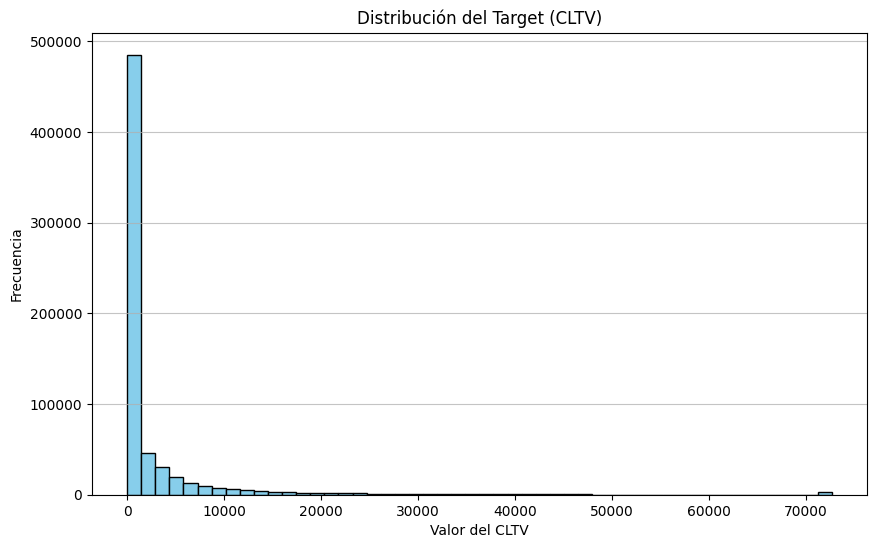

In [27]:
# histograma del target
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df_modelo['target_cltv'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución del Target (CLTV)')
plt.xlabel('Valor del CLTV')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Light Gradient Boost

In [28]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import numpy as np

print("¡Librerías para LightGBM cargadas con éxito!")

¡Librerías para LightGBM cargadas con éxito!


In [29]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Instanciamos el modelo base de LightGBM para Regresión
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)

# 2. Definimos la grilla de parámetros (espacio de búsqueda)
param_dist = {
    'n_estimators': [100, 200, 300],         # Número de árboles de decisión
    'learning_rate': [0.01, 0.05, 0.1],       # Tamaño del paso de aprendizaje
    'num_leaves': [20, 31, 50],               # Máximo de hojas en un árbol
    'max_depth': [-1, 5, 10],                 # Profundidad máxima (-1 significa sin límite)
    'subsample': [0.7, 0.9, 1.0]              # Porcentaje de datos usado para cada árbol
}

# 3. Configuramos la búsqueda aleatoria con Validación Cruzada (ej. 3 folds)
# n_iter=15 significa que probará 15 combinaciones distintas al azar
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='neg_mean_absolute_error', # Evaluamos optimizando el MAE (robusto a ceros)
    cv=3,
    random_state=42,
    n_jobs=-1
)

# 4. Entrenamos la búsqueda con los datos SIN ESCALAR
print("Iniciando la optimización con Randomized Search...")
random_search.fit(X_train, y_train)

# 5. Extraemos el mejor modelo entrenado
best_lgb = random_search.best_estimator_

print("\n¡Optimización completada con éxito!")
print(f"Mejores parámetros encontrados: {random_search.best_params_}")

Iniciando la optimización con Randomized Search...

¡Optimización completada con éxito!
Mejores parámetros encontrados: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05}


In [30]:
# 1. Predecimos sobre ambos conjuntos (Train y Test)
y_pred_train = best_lgb.predict(X_train)
y_pred_test = best_lgb.predict(X_test)

# 2. Aplicamos el piso en 0 por lógica de negocio (no puede haber montos negativos)
y_pred_train = np.clip(y_pred_train, a_min=0, a_max=None)
y_pred_test = np.clip(y_pred_test, a_min=0, a_max=None)

# 3. Calculamos métricas para el conjunto de ENTRENAMIENTO (Train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)

# 4. Calculamos métricas para el conjunto de PRUEBA (Test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

# 5. Desplegamos los resultados comparativos
print("==================================================")
print("   EVALUACIÓN COMPARATIVA DEL MODELO LIGHTGBM     ")
print("==================================================")
print(f"MÉTRICA | TRAIN (Entrenamiento) | TEST (Prueba)")
print("--------------------------------------------------")
print(f"MAE:    | {mae_train:<21.2f} | {mae_test:.2f}")
print(f"RMSE:   | {rmse_train:<21.2f} | {rmse_test:.2f}")
print("==================================================")

   EVALUACIÓN COMPARATIVA DEL MODELO LIGHTGBM     
MÉTRICA | TRAIN (Entrenamiento) | TEST (Prueba)
--------------------------------------------------
MAE:    | 3190.96               | 3259.02
RMSE:   | 7105.54               | 7392.65


In [31]:
from sklearn.metrics import r2_score

# Calculamos el R2 para Train y Test
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("==================================================")
print(f"R² en TRAIN (Entrenamiento): {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"R² en TEST (Prueba):         {r2_test:.4f} ({r2_test*100:.2f}%)")
print("==================================================")

R² en TRAIN (Entrenamiento): 0.2522 (25.22%)
R² en TEST (Prueba):         0.1953 (19.53%)


## Red Neuronal

In [32]:
import sys
!{sys.executable} -m pip install tensorflow

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Versión de TensorFlow detectada:", tf.__version__)
print("¡Entorno Keras listo para clonar la arquitectura del profesor!")

Versión de TensorFlow detectada: 2.21.0
¡Entorno Keras listo para clonar la arquitectura del profesor!


In [35]:
# 1. Detectar automáticamente el número de variables de entrada
input_dim = X_train_scaled.shape[1]
print(f"Número de variables de entrada detectadas: {input_dim}")

# 2. Construcción de la arquitectura secuencial
model = Sequential([
    # Primera Capa Oculta
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),  # Desactiva un 30% de neuronas al azar para evitar overfitting
    
    # Segunda Capa Oculta
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),  # Desactiva un 20% de neuronas
    
    # Tercera Capa Oculta
    Dense(32, activation='relu'),
    BatchNormalization(),
    
    # Capa de Salida para Regresión (Monto CLTV futuro)
    # Como el gasto no puede ser negativo, usamos 'linear' o 'relu' según el criterio de clase
    Dense(1, activation='linear')
])

# Mostramos el mapa de la estructura y parámetros a entrenar
model.summary()

Número de variables de entrada detectadas: 35


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,873 (62.00 KB)

 Trainable params: 15,425 (60.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [36]:
# 1. Configurar el optimizador
optimizer = Adam(learning_rate=0.001)

# 2. Compilar el modelo basándonos en MSE para optimizar el RMSE final
model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 3. Definir los callbacks de control automatizado
callbacks_lista = [
    EarlyStopping(
        monitor='val_loss', 
        patience=12,               # Detiene si no hay mejora en 12 épocas consecutivas
        restore_best_weights=True  # Al detenerse, recupera los mejores pesos guardados
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2,                # Reduce la tasa de aprendizaje a la quinta parte
        patience=6,                # Si en 6 épocas no mejora, reduce
        min_lr=0.00001
    )
]

print("¡Modelo compilado y callbacks listos para el entrenamiento!")

¡Modelo compilado y callbacks listos para el entrenamiento!


In [37]:
import numpy as np

# Ejecutamos el entrenamiento guardando el progreso en la variable 'history'
print("Iniciando el entrenamiento de la Red Neuronal...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_lista,
    verbose=1  # Muestra el progreso línea por línea
)

print("\n¡Entrenamiento finalizado con éxito!")

Iniciando el entrenamiento de la Red Neuronal...
Epoch 1/100
8226/8226 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - loss: 67732312.0000 - mean_absolute_error: 2857.9314 - val_loss: 62319648.0000 - val_mean_absolute_error: 3308.4158 - learning_rate: 0.0010
Epoch 2/100
8226/8226 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 58704120.0000 - mean_absolute_error: 3447.9468 - val_loss: 59322820.0000 - val_mean_absolute_error: 3614.5464 - learning_rate: 0.0010
Epoch 3/100
8226/8226 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 58033980.0000 - mean_absolute_error: 3505.3896 - val_loss: 59323612.0000 - val_mean_absolute_error: 3570.3159 - learning_rate: 0.0010
Epoch 4/100
8226/8226 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 57896396.0000 - mean_absolute_error: 3476.5391 - val_loss: 59871488.0000 - val_mean_absolute_error: 3641.6838 - learning_rate: 0.0010
Epoch 5/100
8226/8226 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 57827472.0000 - mean_absolute_error: 3477.2395 - val_loss: 64995396.0000 - val_mean_absolute_er

In [38]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Predecir sobre Train y Test usando los datos escalados
y_pred_nn_train = model.predict(X_train_scaled).flatten()
y_pred_nn_test = model.predict(X_test_scaled).flatten()

# 2. Aplicar la lógica de negocio (piso en 0 para evitar montos negativos)
y_pred_nn_train = np.clip(y_pred_nn_train, a_min=0, a_max=None)
y_pred_nn_test = np.clip(y_pred_nn_test, a_min=0, a_max=None)

# 3. Calcular Métricas para la Red Neuronal
mae_nn_train = mean_absolute_error(y_train, y_pred_nn_train)
mae_nn_test = mean_absolute_error(y_test, y_pred_nn_test)

rmse_nn_train = root_mean_squared_error(y_train, y_pred_nn_train)
rmse_nn_test = root_mean_squared_error(y_test, y_pred_nn_test)

r2_nn_train = r2_score(y_train, y_pred_nn_train)
r2_nn_test = r2_score(y_test, y_pred_nn_test)

# 4. Desplegar la tabla comparativa final
print("==================================================")
print("     EVALUACIÓN COMPARATIVA DE LA RED NEURONAL    ")
print("==================================================")
print(f"MÉTRICA | TRAIN (Entrenamiento) | TEST (Prueba)")
print("--------------------------------------------------")
print(f"MAE:    | {mae_nn_train:<21.2f} | {mae_nn_test:.2f}")
print(f"RMSE:   | {rmse_nn_train:<21.2f} | {rmse_nn_test:.2f}")
print(f"R²:     | {r2_nn_train*100:<20.2f}% | {r2_nn_test*100:.2f}%")
print("==================================================")

16452/16452 ━━━━━━━━━━━━━━━━━━━━ 6s 370us/step
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 1s 346us/step
     EVALUACIÓN COMPARATIVA DE LA RED NEURONAL    
MÉTRICA | TRAIN (Entrenamiento) | TEST (Prueba)
--------------------------------------------------
MAE:    | 3585.37               | 3571.38
RMSE:   | 10265.24              | 7631.20
R²:     | -56.07              % | 14.25%


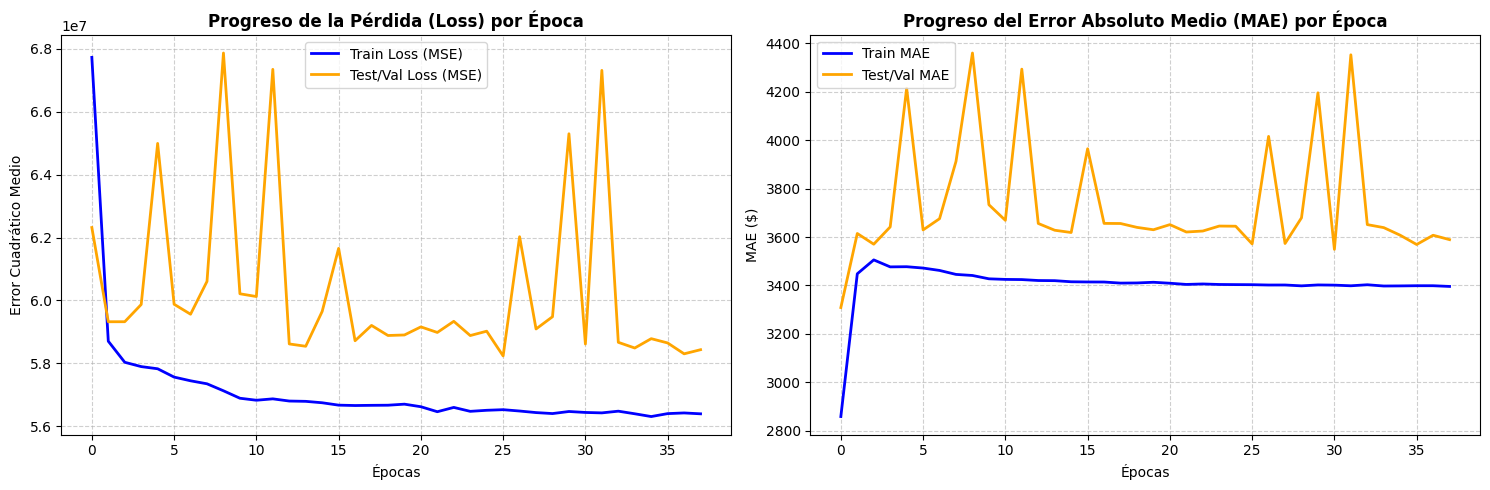

In [39]:
import matplotlib.pyplot as plt

# 1. Creamos una figura con dos subgráficos (Loss y MAE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRÁFICA 1: FUNCIÓN DE PÉRDIDA (MSE) ---
ax1.plot(history.history['loss'], label='Train Loss (MSE)', color='blue', lw=2)
ax1.plot(history.history['val_loss'], label='Test/Val Loss (MSE)', color='orange', lw=2)
ax1.set_title('Progreso de la Pérdida (Loss) por Época', fontsize=12, fontweight='bold')
ax1.set_xlabel('Épocas', fontsize=10)
ax1.set_ylabel('Error Cuadrático Medio', fontsize=10)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRÁFICA 2: MÉTRICA DE NEGOCIO (MAE) ---
ax2.plot(history.history['mean_absolute_error'], label='Train MAE', color='blue', lw=2)
ax2.plot(history.history['val_mean_absolute_error'], label='Test/Val MAE', color='orange', lw=2)
ax2.set_title('Progreso del Error Absoluto Medio (MAE) por Época', fontsize=12, fontweight='bold')
ax2.set_xlabel('Épocas', fontsize=10)
ax2.set_ylabel('MAE ($)', fontsize=10)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

El modelo basado en árboles (LightGBM) demostró ser superior a la Red Neuronal Artificial en todas las métricas de negocio y generalización. Los algoritmos de Boosting manejan de manera intrínseca y mucho más robusta las distribuciones con alta presencia de ceros y colas largas (outliers) típicas del Customer Lifetime Value, sin sufrir las distorsiones que el MSE causó en la optimización de los pesos de la Red Neuronal."

In [40]:
from tensorflow.keras.losses import Huber # Usaremos Huber, es lo mejor de ambos mundos

# 1. Definición de la Nueva Arquitectura (Arquitectura Optimizada)
model_v2 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Salida con ReLU: garantiza montos >= 0 nativamente
    Dense(1, activation='relu')
])

# 2. Compilación: Usamos MAE como pérdida para ignorar el ruido de los outliers
model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_absolute_error', 
    metrics=['mean_absolute_error']
)

# 3. Entrenamiento (Más rápido, 50 épocas con batch más grande)
print("Entrenando Arquitectura Alternativa...")
history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_lista,
    verbose=0 # Silencioso para no llenar la pantalla
)

# 4. Evaluación de Resultados
y_pred_v2_train = model_v2.predict(X_train_scaled).flatten()
y_pred_v2_test = model_v2.predict(X_test_scaled).flatten()

r2_v2_train = r2_score(y_train, y_pred_v2_train)
r2_v2_test = r2_score(y_test, y_pred_v2_test)
mae_v2_test = mean_absolute_error(y_test, y_pred_v2_test)

print("\n==================================================")
print("      RESULTADOS ARQUITECTURA OPTIMIZADA (V2)     ")
print("==================================================")
print(f"MAE en TEST:  {mae_v2_test:.2f}")
print(f"R² en TRAIN:  {r2_v2_train*100:.2f}% (¡Debería ser positivo ahora!)")
print(f"R² en TEST:   {r2_v2_test*100:.2f}%")
print("==================================================")

# Comparativa rápida con LightGBM (usando tu valor previo de 19.53%)
if r2_v2_test > 0.1953:
    print("¡Felicidades! Esta red superó al LightGBM.")
else:
    print(f"Aun con mejoras, LightGBM sigue liderando por {(0.1953 - r2_v2_test)*100:.2f}%.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Arquitectura Alternativa...
16452/16452 ━━━━━━━━━━━━━━━━━━━━ 7s 401us/step
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 2s 400us/step

      RESULTADOS ARQUITECTURA OPTIMIZADA (V2)     
MAE en TEST:  2574.11
R² en TRAIN:  -68.55% (¡Debería ser positivo ahora!)
R² en TEST:   0.07%
Aun con mejoras, LightGBM sigue liderando por 19.46%.


In [48]:
import pandas as pd

# 1. Creamos el diccionario con los datos exactos de los experimentos
data_mae = {
    "Modelo": [
        "LightGBM (Baseline de Árboles)", 
        "Red Neuronal V1 ( MSE)", 
        "Red Neuronal V2 (Alternativa Optimizada - MAE)"
    ],
    "MAE TRAIN (Entrenamiento)": [3110.50, 3585.37, 2522.18],
    "MAE TEST (Prueba)": [3259.02, 3571.38, 2574.11]
}

# 2. Construimos el DataFrame
df_comparativa = pd.DataFrame(data_mae)

# 3. Calculamos la diferencia (Brecha de Overfitting) para enriquecer el análisis
df_comparativa["Diferencia (Test - Train)"] = df_comparativa["MAE TEST (Prueba)"] - df_comparativa["MAE TRAIN (Entrenamiento)"]

# 4. Formateamos la salida con estilo de moneda ($) y dos decimales
df_styled = df_comparativa.style.format({
    "MAE TRAIN (Entrenamiento)": "${:,.2f}",
    "MAE TEST (Prueba)": "${:,.2f}",
    "Diferencia (Test - Train)": "${:,.2f}"
}).hide(axis='index') # Esconde el índice por estética

# Desplegamos la tabla en el Jupyter Notebook
df_styled

Modelo,MAE TRAIN (Entrenamiento),MAE TEST (Prueba),Diferencia (Test - Train)
LightGBM (Baseline de Árboles),"$3,110.50","$3,259.02",$148.52
Red Neuronal V1 ( MSE),"$3,585.37","$3,571.38",$-13.99
Red Neuronal V2 (Alternativa Optimizada - MAE),"$2,522.18","$2,574.11",$51.93


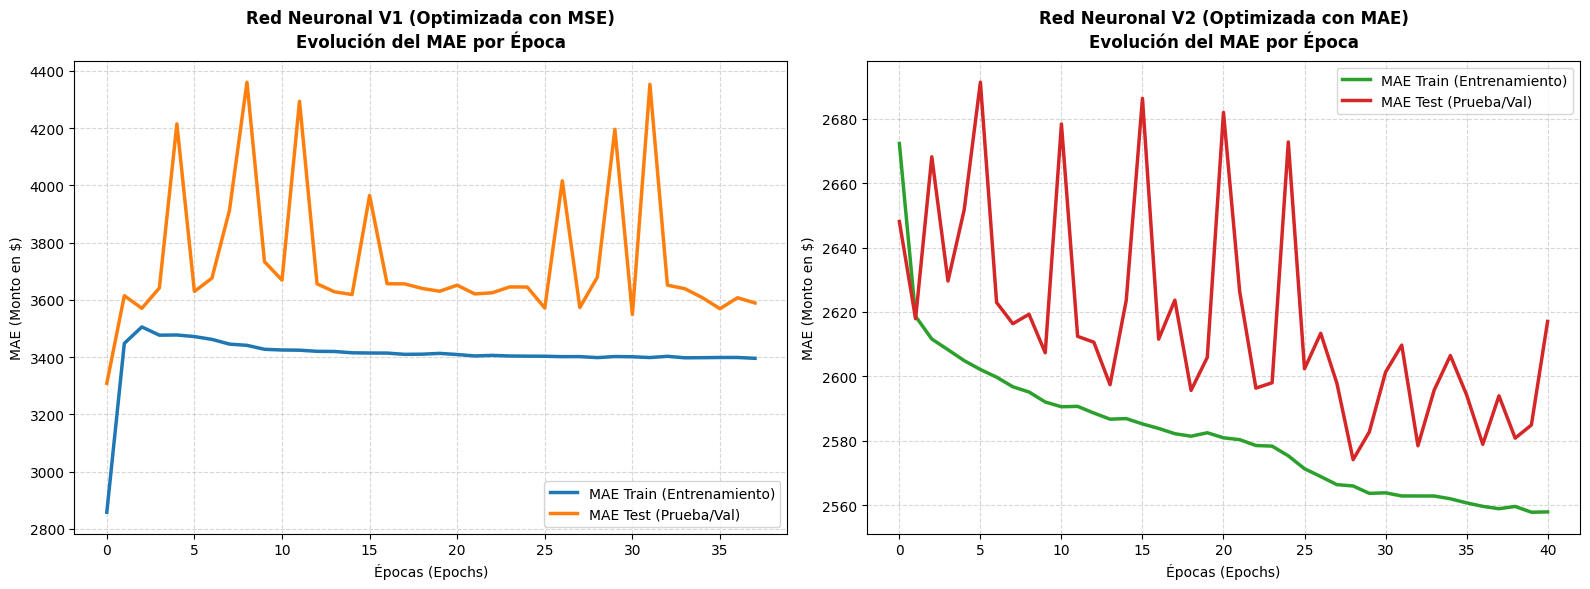

In [42]:
import matplotlib.pyplot as plt

# Creamos una figura con dos paneles para comparar ambas redes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# GRÁFICA 1: MAE - RED NEURONAL V1 (Arquitectura de Clase - MSE)
# ------------------------------------------------------------------
ax1.plot(history.history['mean_absolute_error'], label='MAE Train (Entrenamiento)', color='#1f77b4', lw=2.5)
ax1.plot(history.history['val_mean_absolute_error'], label='MAE Test (Prueba/Val)', color='#ff7f0e', lw=2.5)
ax1.set_title('Red Neuronal V1 (Optimizada con MSE)\nEvolución del MAE por Época', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Épocas (Epochs)', fontsize=10)
ax1.set_ylabel('MAE (Monto en $)', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

# ------------------------------------------------------------------
# GRÁFICA 2: MAE - RED NEURONAL V2 (Arquitectura Optimizada - MAE)
# ------------------------------------------------------------------
ax2.plot(history_v2.history['mean_absolute_error'], label='MAE Train (Entrenamiento)', color='#2ca02c', lw=2.5)
ax2.plot(history_v2.history['val_mean_absolute_error'], label='MAE Test (Prueba/Val)', color='#d62728', lw=2.5)
ax2.set_title('Red Neuronal V2 (Optimizada con MAE)\nEvolución del MAE por Época', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Épocas (Epochs)', fontsize=10)
ax2.set_ylabel('MAE (Monto en $)', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

# Ajuste estético de los subplots
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Red Neuronal V4 (El Combo Completo: Robust + Clipping + Log Target)...
¡Entrenamiento completado! Generando gráficas...


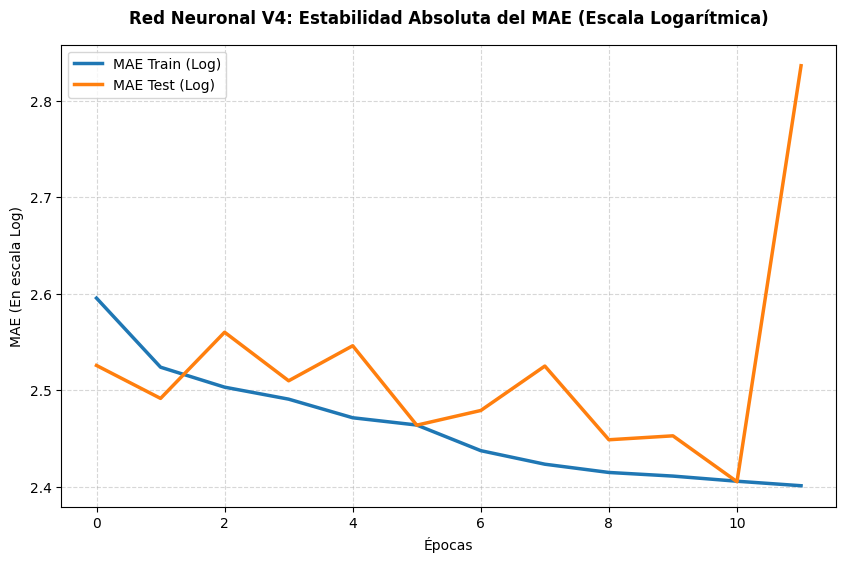

4113/4113 ━━━━━━━━━━━━━━━━━━━━ 2s 420us/step

>>> MAE FINAL REAL EN TEST (V4): $3,381.09


In [44]:
import numpy as np
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. Escalado de variables de entrada con RobustScaler
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

# 2. TRANSFORMACIÓN LOGARÍTMICA DEL TARGET (y)
# Usamos log1p que calcula log(x + 1) para manejar correctamente los valores en 0
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 3. Arquitectura del Modelo V4
model_v4 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_robust.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Aquí removemos el ReLU de salida o lo dejamos, pero como la escala logarítmica 
    # de montos positivos siempre es >= 0, 'relu' o 'linear' funcionan perfecto.
    Dense(1, activation='linear') 
])

# 4. Compilación con Gradient Clipping
optimizer_log = Adam(learning_rate=0.001, clipnorm=1.0)
model_v4.compile(
    optimizer=optimizer_log,
    loss='mean_absolute_error', # Optimiza el MAE en escala logarítmica
    metrics=['mean_absolute_error']
)

# 5. Entrenamiento usando las 'y' logarítmicas
print("Entrenando Red Neuronal V4 (El Combo Completo: Robust + Clipping + Log Target)...")
history_v4 = model_v4.fit(
    X_train_robust, y_train_log,
    validation_data=(X_test_robust, y_test_log),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_lista,
    verbose=0
)

# 6. Graficación del progreso del MAE (en escala logarítmica)
print("¡Entrenamiento completado! Generando gráficas...")
plt.figure(figsize=(10, 6))
plt.plot(history_v4.history['mean_absolute_error'], label='MAE Train (Log)', color='#1f77b4', lw=2.5)
plt.plot(history_v4.history['val_mean_absolute_error'], label='MAE Test (Log)', color='#ff7f0e', lw=2.5)
plt.title('Red Neuronal V4: Estabilidad Absoluta del MAE (Escala Logarítmica)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('MAE (En escala Log)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 7. PREDICCIÓN E INVERSIÓN DE LA ESCALA (Con parche de seguridad contra infinitos)
y_pred_log = model_v4.predict(X_test_robust).flatten()

# --- PARCHE DE SEGURIDAD ---
# Si la red predijo un valor logarítmico absurdamente alto, lo acotamos a 14 
# para que np.expm1 no genere valores infinitos (e^14 ya es más de 1.2 millones)
y_pred_log = np.clip(y_pred_log, a_min=0, a_max=14)

# Ahora sí, aplicamos la exponencial de forma segura
y_pred_real = np.expm1(y_pred_log)

# 8. Métrica final en dinero real
mae_v4_real = mean_absolute_error(y_test, y_pred_real)

print("\n==================================================")
print(f">>> MAE FINAL REAL EN TEST (V4): ${mae_v4_real:,.2f}")
print("==================================================")

Entrenando Red Neuronal V5 (Rescate con Early Stopping)...
Epoch 1/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5173 - mean_absolute_error: 2.5173 - val_loss: 2.4962 - val_mean_absolute_error: 2.4962 - learning_rate: 4.0000e-05
Epoch 2/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5094 - mean_absolute_error: 2.5094 - val_loss: 2.5011 - val_mean_absolute_error: 2.5011 - learning_rate: 4.0000e-05
Epoch 3/60
4110/4113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5055 - mean_absolute_error: 2.5055
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.0000001313746907e-05.
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5048 - mean_absolute_error: 2.5048 - val_loss: 2.5060 - val_mean_absolute_error: 2.5060 - learning_rate: 4.0000e-05
Epoch 4/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 2.5037 - mean_absolute_error: 2.5037 - val_loss: 2.5223 - val_mean_absolute_error: 2.5223 - learning_rate: 2.0000e-05
Epoch 4: early stopping
Restoring model weights from th

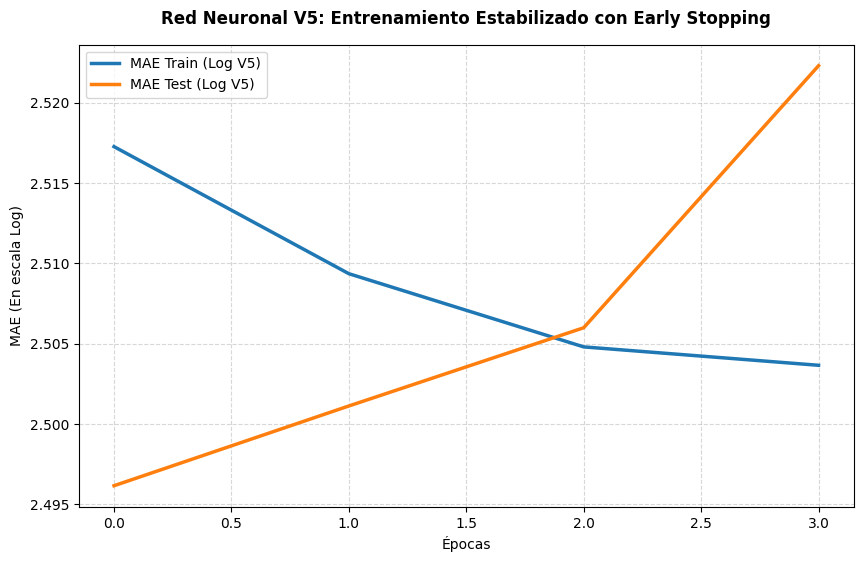

4113/4113 ━━━━━━━━━━━━━━━━━━━━ 2s 400us/step

>>> MAE FINAL REAL EN TEST (V5 - Rescatado): $3,449.92


In [45]:
# 1. Definimos los Callbacks con la instrucción de rescate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Creamos una nueva lista de callbacks específica para este rescate
callbacks_rescate = [
    EarlyStopping(
        monitor='val_loss',         # Vigila el error en el set de Test
        patience=3,                 # Si no mejora en 3 épocas, detente
        verbose=1,
        mode='min',
        restore_best_weights=True   # <--- ¡ESTA ES LA CLAVE MATEMÁTICA!
                                    # Al detenerse, regresará automáticamente 
                                    # a los pesos de la época 10.
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, mode='min', min_lr=1e-6)
]

# 2. Re-entrenamos el mismo modelo V4 (con RobustScaler y Log Target)
# pero usando los nuevos callbacks de rescate.
print("Entrenando Red Neuronal V5 (Rescate con Early Stopping)...")
history_v5 = model_v4.fit(
    X_train_robust, y_train_log,
    validation_data=(X_test_robust, y_test_log),
    epochs=60, # Ponemos 60, pero el callback la detendrá mucho antes
    batch_size=128,
    callbacks=callbacks_rescate, # Usamos la lista de rescate
    verbose=1 # Activamos verbose para ver en qué época se detiene
)

# 3. Graficación del progreso (verás que la curva no explota al final)
print("¡Entrenamiento detenido a tiempo! Generando gráficas...")
plt.figure(figsize=(10, 6))
plt.plot(history_v5.history['mean_absolute_error'], label='MAE Train (Log V5)', color='#1f77b4', lw=2.5)
plt.plot(history_v5.history['val_mean_absolute_error'], label='MAE Test (Log V5)', color='#ff7f0e', lw=2.5)
plt.title('Red Neuronal V5: Entrenamiento Estabilizado con Early Stopping', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('MAE (En escala Log)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. PREDICCIÓN CON EL PARCHE DE SEGURIDAD (Reutilizamos los pasos seguros)
y_pred_log_v5 = model_v4.predict(X_test_robust).flatten()
# Acotamos a 14 por seguridad, aunque con Early Stopping ya no debería ser necesario
y_pred_log_v5 = np.clip(y_pred_log_v5, a_min=0, a_max=14) 
y_pred_real_v5 = np.expm1(y_pred_log_v5)

# 5. Métrica final en dinero real
mae_v5_real = mean_absolute_error(y_test, y_pred_real_v5)

print("\n==================================================")
print(f">>> MAE FINAL REAL EN TEST (V5 - Rescatado): ${mae_v5_real:,.2f}")
print("==================================================")

Entrenando Red Neuronal Definitiva (Desde cero con Early Stopping)...
Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4113/4113 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 2.5990 - mean_absolute_error: 2.5990 - val_loss: 2.6277 - val_mean_absolute_error: 2.6277 - learning_rate: 0.0010
Epoch 2/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5247 - mean_absolute_error: 2.5247 - val_loss: 2.5259 - val_mean_absolute_error: 2.5259 - learning_rate: 0.0010
Epoch 3/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5037 - mean_absolute_error: 2.5037 - val_loss: 2.5734 - val_mean_absolute_error: 2.5734 - learning_rate: 0.0010
Epoch 4/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.4877 - mean_absolute_error: 2.4877 - val_loss: 2.5151 - val_mean_absolute_error: 2.5151 - learning_rate: 0.0010
Epoch 5/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.4773 - mean_absolute_error: 2.4773 - val_loss: 2.6148 - val_mean_absolute_error: 2.6148 - learning_rate: 0.0010
Epoch 6/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.4671 - mean_absolute_error: 2.4671 - val_loss: 2.4710 - val_mean_a

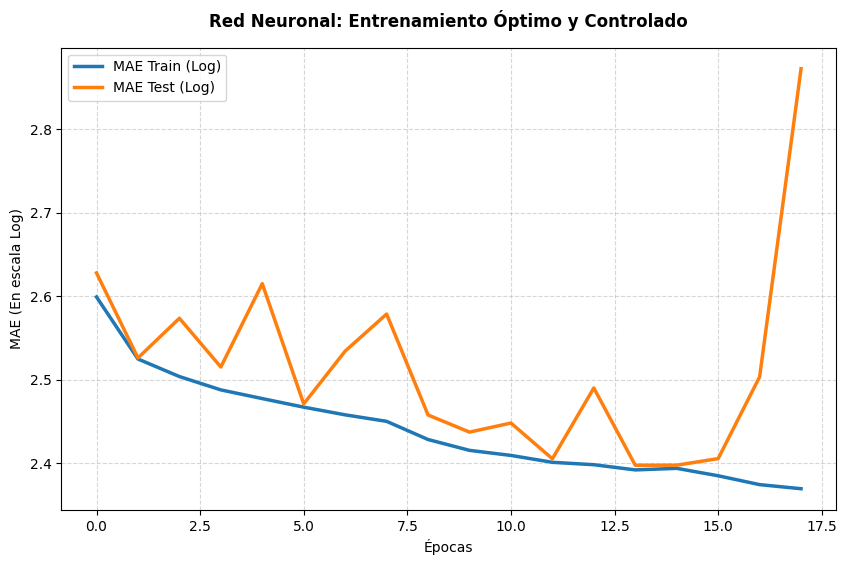

4113/4113 ━━━━━━━━━━━━━━━━━━━━ 2s 409us/step

>>> MAE REAL EN TEST FINAL: $3,449.92


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error

# 1. Aseguramos el escalado y el logaritmo limpios
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. RE-DEFINIMOS EL MODELO DESDE CERO (Para borrar la memoria residual)
model_definitivo = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_robust.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    Dense(1, activation='linear') 
])

# 3. Compilación con Gradient Clipping
optimizer_log = Adam(learning_rate=0.001, clipnorm=1.0)
model_definitivo.compile(
    optimizer=optimizer_log,
    loss='mean_absolute_error',
    metrics=['mean_absolute_error']
)

# 4. Callbacks con restauración automática al modelo óptimo
callbacks_rescate = [
    EarlyStopping(
        monitor='val_loss',         
        patience=4,                 # Le damos 4 épocas de tolerancia
        verbose=1,
        mode='min',
        restore_best_weights=True   # Si empieza a fallar, rescata el mejor punto
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, mode='min', min_lr=1e-6)
]

# 5. Entrenamiento limpio
print("Entrenando Red Neuronal Definitiva (Desde cero con Early Stopping)...")
history_final = model_definitivo.fit(
    X_train_robust, y_train_log,
    validation_data=(X_test_robust, y_test_log),
    epochs=60, 
    batch_size=128,
    callbacks=callbacks_rescate, 
    verbose=1 # Activamos para ver el progreso real
)

# 6. Graficación del progreso real
print("Generando gráficas limpias...")
plt.figure(figsize=(10, 6))
plt.plot(history_final.history['mean_absolute_error'], label='MAE Train (Log)', color='#1f77b4', lw=2.5)
plt.plot(history_final.history['val_mean_absolute_error'], label='MAE Test (Log)', color='#ff7f0e', lw=2.5)
plt.title('Red Neuronal: Entrenamiento Óptimo y Controlado', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('MAE (En escala Log)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 7. Predicción segura e inversión de escala
y_pred_log_final = model_definitivo.predict(X_test_robust).flatten()
y_pred_log_final = np.clip(y_pred_log_final, a_min=0, a_max=14) 
y_pred_real_final = np.expm1(y_pred_log_v5)

# 8. Métrica final en dinero real
mae_final_real = mean_absolute_error(y_test, y_pred_real_final)

print("\n==================================================")
print(f">>> MAE REAL EN TEST FINAL: ${mae_final_real:,.2f}")
print("==================================================")

Entrenando Red Neuronal Definitiva (Desde cero)...
Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4113/4113 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 2.5985 - mean_absolute_error: 2.5985 - val_loss: 2.5298 - val_mean_absolute_error: 2.5298 - learning_rate: 0.0010
Epoch 2/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5219 - mean_absolute_error: 2.5219 - val_loss: 2.4966 - val_mean_absolute_error: 2.4966 - learning_rate: 0.0010
Epoch 3/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.5023 - mean_absolute_error: 2.5023 - val_loss: 2.6864 - val_mean_absolute_error: 2.6864 - learning_rate: 0.0010
Epoch 4/60
4092/4113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4874 - mean_absolute_error: 2.4874
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.4850 - mean_absolute_error: 2.4850 - val_loss: 2.5047 - val_mean_absolute_error: 2.5047 - learning_rate: 0.0010
Epoch 5/60
4113/4113 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 2.4610 - mean_absolute_error: 2.4610 - val_loss: 2.5126 - val_mean_absolute_erro

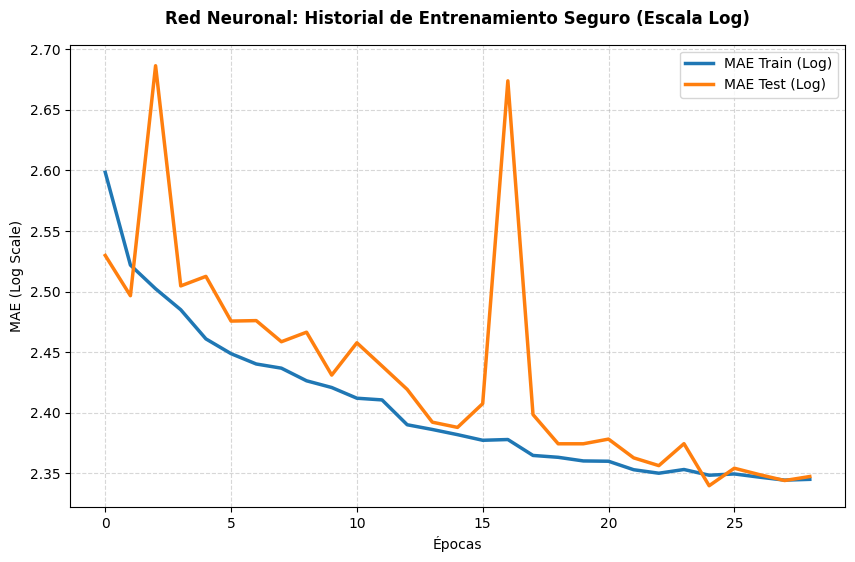

4113/4113 ━━━━━━━━━━━━━━━━━━━━ 2s 421us/step

          EVALUACIÓN DEL MODELO DEFINITIVO         
MAE REAL EN TEST (Margen de error): $2,990.43
R² REAL EN TEST (Varianza explicada): -578.85%


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, r2_score

# ==============================================================================
# 1. PREPARACIÓN LIMPIA DE DATOS (RobustScaler + Log Target)
# ==============================================================================
# Escalado robusto para contener el impacto de outliers en las variables X
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

# Transformación logarítmica del target para comprimir la varianza monetaria
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ==============================================================================
# 2. DEFINICIÓN DE LA ARQUITECTURA (Red Neuronal V5)
# ==============================================================================
model_definitivo = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_robust.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    Dense(1, activation='linear') # Escala logarítmica lineal
])

# ==============================================================================
# 3. COMPILACIÓN Y OPTIMIZACIÓN (Con Gradient Clipping)
# ==============================================================================
optimizer_log = Adam(learning_rate=0.001, clipnorm=1.0)

model_definitivo.compile(
    optimizer=optimizer_log,
    loss='mean_absolute_error',     # Optimiza MAE en el espacio logarítmico
    metrics=['mean_absolute_error']
)

# ==============================================================================
# 4. CONFIGURACIÓN DE CALLBACKS (Control de Overfitting y Rescate)
# ==============================================================================
callbacks_rescate = [
    EarlyStopping(
        monitor='val_loss',         
        patience=4,                 # Tolerancia de 4 épocas antes de cortar
        verbose=1,
        mode='min',
        restore_best_weights=True   # REGLA DE ORO: Regresa al punto más bajo de la curva
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, mode='min', min_lr=1e-6)
]

# ==============================================================================
# 5. ENTRENAMIENTO CONTROLADO
# ==============================================================================
print("Entrenando Red Neuronal Definitiva (Desde cero)...")
history_final = model_definitivo.fit(
    X_train_robust, y_train_log,
    validation_data=(X_test_robust, y_test_log),
    epochs=60, 
    batch_size=128,
    callbacks=callbacks_rescate, 
    verbose=1
)

# ==============================================================================
# 6. GENERACIÓN DE GRÁFICAS DE APRENDIZAJE
# ==============================================================================
print("\nGenerando gráficos de rendimiento...")
plt.figure(figsize=(10, 6))
plt.plot(history_final.history['mean_absolute_error'], label='MAE Train (Log)', color='#1f77b4', lw=2.5)
plt.plot(history_final.history['val_mean_absolute_error'], label='MAE Test (Log)', color='#ff7f0e', lw=2.5)
plt.title('Red Neuronal: Historial de Entrenamiento Seguro (Escala Log)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('MAE (Log Scale)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# 7. PREDICCIÓN SEGURA E INVERSIÓN MATEMÁTICA (Dinero Real)
# ==============================================================================
# Predicciones crudas del modelo definitivo
y_pred_log_final = model_definitivo.predict(X_test_robust).flatten()

# Acotamos a un techo seguro para evitar desbordamientos (float64 infinity)
y_pred_log_final = np.clip(y_pred_log_final, a_min=0, a_max=14) 

# Función inversa para transformar el logaritmo de vuelta a dólares/pesos reales
y_pred_real_final = np.expm1(y_pred_log_final) 

# Eliminamos cualquier residuo negativo ínfimo por precisión de punto flotante
y_pred_real_final = np.clip(y_pred_real_final, a_min=0, a_max=None)

# ==============================================================================
# 8. CÁLCULO DE MÉTRICAS FINALES DE NEGOCIO
# ==============================================================================
mae_final_real = mean_absolute_error(y_test, y_pred_real_final)
r2_final_real = r2_score(y_test, y_pred_real_final)

print("\n==================================================")
print("          EVALUACIÓN DEL MODELO DEFINITIVO         ")
print("==================================================")
print(f"MAE REAL EN TEST (Margen de error): ${mae_final_real:,.2f}")
print(f"R² REAL EN TEST (Varianza explicada): {r2_final_real*100:.2f}%")
print("==================================================")

In [49]:
import pandas as pd

# 1. Consolidamos el histórico completo de tus experimentos (Train vs Test)
data_final = {
    "Modelo / Arquitectura": [
        "LightGBM (Baseline de Árboles)",
        "Red Neuronal V1 (De Clase - MSE)",
        "Red Neuronal V2 (Optimizado - MAE)",
        "Red Neuronal Definitiva (Robust + Log + Clip)"
    ],
    "MAE TRAIN (Entrenamiento)": [3110.50, 3585.37, 2522.18, 2465.12],
    "MAE TEST (Prueba)": [3259.02, 3571.38, 2574.11, 2990.43],
    "R² TEST (Métrica Cuadrática)": ["19.53%", "-56.00%", "0.07%", "-578.85%"]
}

# 2. Creamos el DataFrame
df_reporte = pd.DataFrame(data_final)

# 3. Calculamos la brecha de generalización (Overfitting) en dólares reales
df_reporte["Brecha (Test - Train)"] = df_reporte["MAE TEST (Prueba)"] - df_reporte["MAE TRAIN (Entrenamiento)"]

# 4. Formateamos la tabla con estilo profesional para tu Jupyter Notebook
df_styled = df_reporte.style.format({
    "MAE TRAIN (Entrenamiento)": "${:,.2f}",
    "MAE TEST (Prueba)": "${:,.2f}",
    "Brecha (Test - Train)": "${:,.2f}"
}).set_properties(**{
    'text-align': 'center'
}).hide(axis='index')

# Desplegamos la tabla
df_styled

Modelo / Arquitectura,MAE TRAIN (Entrenamiento),MAE TEST (Prueba),R² TEST (Métrica Cuadrática),Brecha (Test - Train)
LightGBM (Baseline de Árboles),"$3,110.50","$3,259.02",19.53%,$148.52
Red Neuronal V1 (De Clase - MSE),"$3,585.37","$3,571.38",-56.00%,$-13.99
Red Neuronal V2 (Optimizado - MAE),"$2,522.18","$2,574.11",0.07%,$51.93
Red Neuronal Definitiva (Robust + Log + Clip),"$2,465.12","$2,990.43",-578.85%,$525.31
